In [ ]:
!pip install qiskit
!pip install pylatexenc
!pip install qiskit_aer

# 🔐 E91 Quantum Key Distribution Lab

This Jupyter notebook walks you through a complex simulation of the E91 Quantum Key Distribution (QKD) protocol using Qiskit. It includes:
- EPR entanglement generation
- Measurement in different bases
- Eavesdropper simulation (Eve)
- Bell inequality test (CHSH inequality)
- Visualization and comparison


In [ ]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np
import random


## Define Measurement Bases
E91 uses different measurement settings for Alice and Bob:
- Alice: Z, X, W (Z+X)
- Bob: W (Z+X), X, V (Z−X)
This function rotates the qubits into the desired basis before measurement.

**Measurement Settings in E91**

In quantum mechanics, when we say someone measures in the Z, X, or any other basis, we're talking about the axis along which they perform a measurement on a qubit, usually by rotating the qubit so that a Z-basis measurement (the default in Qiskit) actually reflects the intended measurement direction.

Here’s what each one means:

🟩 Z basis
- Standard computational basis

- Measures in ∣0⟩ and ∣1⟩

- Bloch sphere direction: along the Z-axis

🟦 X basis
- Also called the Hadamard basis

- Measures in: 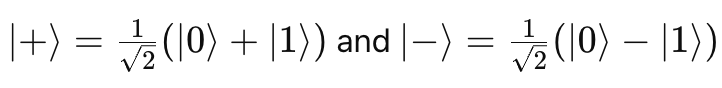

- Achieved by applying a Hadamard gate before measuring

- Bloch sphere direction: along the X-axis

🟨 W basis ≈ (Z + X)/√2 direction
- A diagonal direction halfway between Z and X

- Not a standard basis — implemented as a specific rotation:

𝑊 = 𝐻⋅𝑆

- This rotates the qubit so that a standard Z-measurement corresponds to this in-between direction

- Think of it as +45° rotation in the Bloch sphere’s X-Z plane

🟥 V basis ≈ (Z − X)/√2 direction
- Another in-between basis, orthogonal to W

- Implemented as: 𝑉 = 𝑆†⋅𝐻 (In case you don't know, † is a dagger sign.)

- Think of it as −45° rotation in the Bloch sphere’s X-Z plane

**Why Use W and V?**

In the E91 protocol, Alice and Bob use various bases to:

- Ensure that their measurements are correlated when they use aligned directions (e.g., X vs. X).

- Detect Eve using Bell’s inequality, which is sensitive to correlations along specific angle combinations — not just 0° or 90°, but also ±45°.

Explore qiskit documentation for S and S† notation.



In [ ]:
def apply_basis(qc, qubit, basis):
    if basis == 'Z':
        pass
    elif basis == 'X':
        qc.h(qubit)
    elif basis == 'W':
        qc.h(qubit)
        qc.s(qubit)
    elif basis == 'V':
        qc.sdg(qubit)
        qc.h(qubit)
    else:
        raise ValueError("Unknown basis")

## Create EPR Pair
We create an entangled Bell pair (|00⟩ + |11⟩)/√2 using an H gate followed by a CNOT gate.
Alice and Bob each receive one qubit from this pair.

In [ ]:
def create_epr_pair():
    qreg = QuantumRegister(2)
    creg = ClassicalRegister(2)
    qc = QuantumCircuit(qreg, creg)
    qc.h(qreg[0])
    qc.cx(qreg[0], qreg[1])
    return qc, qreg, creg

## Single Trial of E91
A single E91 trial simulates both parties measuring their entangled qubits in randomly chosen bases and recording the outcomes.

In [ ]:
def single_e91_trial(alice_basis, bob_basis):
    qc, qreg, creg = create_epr_pair()
    apply_basis(qc, qreg[0], alice_basis)
    apply_basis(qc, qreg[1], bob_basis)
    qc.measure(qreg[0], creg[0])
    qc.measure(qreg[1], creg[1])

    backend = AerSimulator()
    compiled = transpile(qc, backend)
    result = backend.run(compiled, shots=1).result()
    counts = result.get_counts()
    return list(counts.keys())[0]

## Run Trials and Extract Correlations
We run many E91 trials using random bases and collect the results.
Only specific basis pairs are used to calculate Bell inequality violations.

In [ ]:
alice_bases = ['Z', 'X', 'W']
bob_bases   = ['W', 'X', 'V']
n_trials = 1000
raw_results = []
for _ in range(n_trials):
    a_basis = random.choice(alice_bases)
    b_basis = random.choice(bob_bases)
    result = single_e91_trial(a_basis, b_basis)
    raw_results.append((a_basis, b_basis, result))

In [ ]:
def extract_correlations(data):
    bell_pairs = [('Z','X'), ('X','W'), ('X','X'), ('W','V')]
    correlations = []
    for a_basis, b_basis, result in data:
        if (a_basis, b_basis) in bell_pairs:
            a, b = int(result[1]), int(result[0])
            parity = 1 if a == b else -1
            correlations.append(((a_basis, b_basis), parity))
    return correlations
correlations = extract_correlations(raw_results)

## Compute Bell CHSH Parameter
We calculate the CHSH S value using four specific expectation values:
- E(A0,B1), E(A1,B0), E(A1,B1), E(A2,B2)
S > 2 means quantum correlations (entanglement) exist. S ≤ 2 could indicate interference or no entanglement.

In [ ]:
from collections import defaultdict
def compute_bell_violation(correlations):
    corr_dict = defaultdict(list)
    for (a_basis, b_basis), parity in correlations:
        corr_dict[(a_basis, b_basis)].append(parity)
    def mean(corrs): return np.mean(corrs) if corrs else 0
    E_WV = mean(corr_dict[('W', 'V')])
    E_XW = mean(corr_dict[('X', 'W')])
    E_ZX = mean(corr_dict[('Z', 'X')])
    E_XX = mean(corr_dict[('X', 'X')])
    S = E_ZX + E_XW + E_XX - E_WV
    return S
S_value = compute_bell_violation(correlations)
print(f"CHSH Bell parameter S = {S_value:.2f}")

CHSH Bell parameter S = 1.90


## Eve Intercept-and-Resend Simulation
We simulate Eve intercepting Bob’s qubit, measuring it in a random basis, and resending a new qubit to Bob.
This attack can destroy the entanglement and reduce the S value.

In [ ]:
def eve_intercepts(qc, qreg, eve_basis):
    apply_basis(qc, qreg[1], eve_basis)
    qc.measure(qreg[1], 1)
    qc.reset(qreg[1])
    if random.choice([0,1]):
        qc.x(qreg[1])
    return qc

In [ ]:
def single_e91_trial_with_eve(alice_basis, bob_basis, eve_basis):
    qc, qreg, creg = create_epr_pair()
    eve_intercepts(qc, qreg, eve_basis)
    apply_basis(qc, qreg[0], alice_basis)
    apply_basis(qc, qreg[1], bob_basis)
    qc.measure(qreg[0], creg[0])
    qc.measure(qreg[1], creg[1])
    backend = AerSimulator()
    compiled = transpile(qc, backend)
    result = backend.run(compiled, shots=1).result()
    counts = result.get_counts()
    return list(counts.keys())[0]

In [ ]:
raw_results_eve = []
for _ in range(n_trials):
    a_basis = random.choice(alice_bases)
    b_basis = random.choice(bob_bases)
    e_basis = random.choice(bob_bases)
    result = single_e91_trial_with_eve(a_basis, b_basis, e_basis)
    raw_results_eve.append((a_basis, b_basis, result))
correlations_eve = extract_correlations(raw_results_eve)
S_value_eve = compute_bell_violation(correlations_eve)
print(f"CHSH Bell parameter with Eve S = {S_value_eve:.2f}")

CHSH Bell parameter with Eve S = 0.13


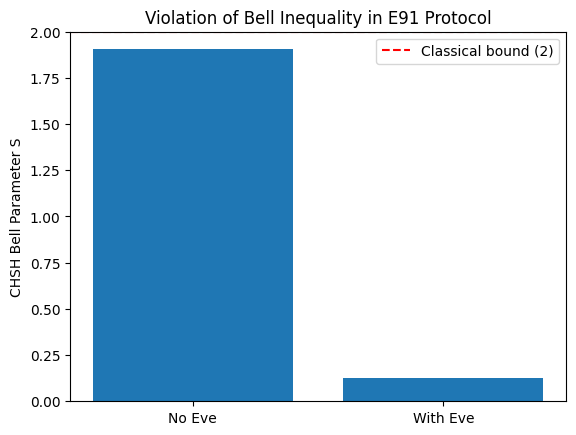

In [ ]:
fig, ax = plt.subplots()
ax.bar(['No Eve', 'With Eve'], [S_value, S_value_eve])
ax.axhline(2, color='red', linestyle='--', label='Classical bound (2)')
ax.set_ylabel("CHSH Bell Parameter S")
ax.set_title("Violation of Bell Inequality in E91 Protocol")
ax.legend()
plt.show()